# shapleyflow — Graph-Based Shapley Path Decomposition

[`shapflow`](https://github.com/nathanwang000/Shapley-Flow) (NeurIPS 2020, *"Shapley Flow: A Graph-based Approach to Interpreting Model Predictions"*) decomposes a prediction's credit not over **features** but over the **edges** of a known causal DAG. This is a fundamentally different output object than standard SHAP / shapiq:

| Library | Output | Requires |
|---|---|---|
| `shap`, `shapiq`, `alibi` | one signed attribution per **feature** | model + background data |
| `shapflow` | one signed attribution per **edge** of a causal DAG | model + background data + **causal mechanisms** (functions `f_node(parents)` for every non-root node) |

Critically, `shapflow.GraphExplainer` does not accept a bare `networkx.DiGraph` — it needs the actual *generative functions* that map each child node's value from its parents. None of the benchmark datasets ship with those, so this notebook does two things:

1. **Section 1 — toy healthcare DAG** (`health_status → scanner_type → mortality_pred`). Mechanisms are hand-coded, so the attribution story is unambiguous and serves as a teaching example of what edge-level credit looks like.
2. **Section 2 — California Housing**. We hand-craft a plausible DAG over the 8 features and fit small auxiliary regressors as the causal mechanisms. This is the smallest project dataset where a meaningful DAG is feasible (see *Why not Ames and Covertype* at the end).

## What we measure

* Wall-clock runtime of `GraphExplainer.shap_values` on each setting.
* Edge-level attribution for one explained instance (rendered via `flow_result.draw(i)`).
* Total credit reaching the target node (should sum to `prediction(foreground) - prediction(background_mean)`, by the efficiency axiom).

We do **not** compare these numbers to the shapiq / alibi notebooks: they are different mathematical objects (edge weights vs feature weights). The comparison is qualitative — what new structure does the flow view surface that feature-level Shapley values cannot?

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from shapflow.flow import Node, Graph, GraphExplainer, sample_graph


def show_edge_credits(flow_result, idx: int = 0) -> None:
    """Render edge-level attributions for explained instance `idx`.

    Tries `flow_result.draw(idx)` first (renders a DOT graph via pygraphviz).
    If pygraphviz is not installed, falls back to a sorted text listing of
    edge credits.  The numerical content is identical either way.
    """
    try:
        flow_result.draw(idx)
        return
    except (ModuleNotFoundError, ImportError):
        pass  # pygraphviz missing; fall through to text

    # Text fallback -- read the per-instance edge credit dict directly.
    if hasattr(flow_result, "ecs") and len(flow_result.ecs) > idx:
        ec = flow_result.ecs[idx]
    elif hasattr(flow_result, "edge_credit"):
        ec = flow_result.edge_credit
    else:
        print(f"  (unable to extract edge credits from {type(flow_result).__name__})")
        return

    rows = []
    for parent_name, children in ec.items():
        for child_name, val in children.items():
            if isinstance(val, (int, float, np.floating)) and val != 0:
                rows.append((parent_name, child_name, float(val)))

    rows.sort(key=lambda r: abs(r[2]), reverse=True)
    width = max((len(p) for p, _, _ in rows), default=10)
    for parent_name, child_name, val in rows:
        print(f"  {parent_name:>{width}s}  -->  {child_name:<15s}  {val:+.4f}")

## Section 1 — Toy healthcare DAG

```
    health_status ──► scanner_type ──► mortality_pred
                 └─────────────────────►┘
```

* `health_status` is the root (exogenous).
* `scanner_type` is *caused by* `health_status` (sicker patients get sent to a different scanner). Mechanism: `scanner_type = 1 - health_status`.
* The model `mortality_pred` literally uses only `scanner_type` (`f(h, s) = s`).

Classical Shapley would assign all credit to `scanner_type` because the model never reads `health_status`. Shapley-Flow sees that `scanner_type` is *caused by* `health_status` and propagates credit backwards along the causal edge — surfacing the upstream driver that the model implicitly uses.

ShapleyFlow runtime (toy DAG): 0.004s
Edge attributions for the single foreground instance:


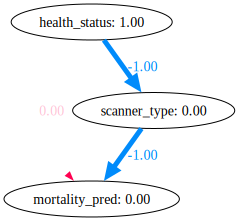

In [2]:
def build_health_graph() -> Graph:
    x1 = Node("health_status")
    x2 = Node("scanner_type",  lambda h: 1 - h, [x1])
    y  = Node("mortality_pred", lambda h, s: s, [x1, x2], is_target_node=True)
    return Graph([x1, x2, y])

g_toy = build_health_graph()

# Sample one background row (healthy patient) and one foreground row (sick).
# sample_graph cascades the mechanisms from any fixed root values.
bg_toy = sample_graph(g_toy, {"health_status": 0})[["health_status", "scanner_type"]]
fg_toy = sample_graph(g_toy, {"health_status": 1})[["health_status", "scanner_type"]]

t0 = time.time()
flow_toy = GraphExplainer(g_toy, bg_toy, silent=True).shap_values(fg_toy)
toy_runtime = time.time() - t0

print(f"ShapleyFlow runtime (toy DAG): {toy_runtime:.3f}s")
print("Edge attributions for the single foreground instance:")
show_edge_credits(flow_toy, 0)

## Section 2 — California Housing with a hand-crafted DAG

California has 8 features and clean semantics, so we can fabricate a plausible DAG without it being too speculative:

```
    Latitude, Longitude  ──►  MedInc, HouseAge, Population
                                │           │           │
                                ▼           │           ▼
                             AveRooms ─►─ AveBedrms   AveOccup
                                              │           │
                                              ▼           ▼
                                              └── target ─┘  (RandomForestRegressor)
```

**Mechanisms.** For each non-root node we fit a small `LinearRegression` from its parents using `X.iloc[:100]` (the same background slice as the alibi / shap / shapiq notebooks). Linear regression is intentional: the mechanism just needs to be a smooth extrapolator that lets `GraphExplainer` propagate counterfactual values; the *expressive* part of the model is the trained `RandomForestRegressor` sitting at the target node.

**Caveat.** This DAG is a *plausible* one, not the *true* one — there is no ground-truth causal structure for California Housing. Treat the resulting edge attributions as illustrating what flow attribution looks like on real tabular data, not as a definitive causal claim.

In [3]:
from Models.load_and_train import TrainingConfig
from Models.dataset_and_models import Dataset, Model

config = TrainingConfig(Dataset.CALIFORNIA_HOUSING, Model.RANDOM_FOREST_REGRESSOR)
trained_rf = config.train(verbose=True)

data = config.dataset.load_dataset()
X = data["X"]
feature_names = list(data["feature_names"])
print("\nFeature order (must match trained_rf.fit input):")
print(feature_names)

# ShapleyFlow is graph-traversal heavy (O(n! * mechanism_cost) under default
# sampling), so we keep N_EVAL small.  N_BACKGROUND matches the repo-wide
# convention (X.iloc[:100]) used by every other notebook here.
N_BACKGROUND = 100
N_EVAL       = 3

X_background = X.iloc[:N_BACKGROUND].reset_index(drop=True)
X_eval       = X.iloc[N_BACKGROUND : N_BACKGROUND + N_EVAL].reset_index(drop=True)

# --- Auxiliary regressors == causal mechanisms ----------------------------
# Fit on .values (numpy) so later predict() calls on numpy arrays don't trip
# sklearn's "X does not have valid feature names" warning.
aux_medInc     = LinearRegression().fit(X_background[["Latitude", "Longitude"]].values, X_background["MedInc"].values)
aux_houseAge   = LinearRegression().fit(X_background[["Latitude", "Longitude"]].values, X_background["HouseAge"].values)
aux_population = LinearRegression().fit(X_background[["Latitude", "Longitude"]].values, X_background["Population"].values)
aux_aveRooms   = LinearRegression().fit(X_background[["MedInc"]].values,                X_background["AveRooms"].values)
aux_aveBedrms  = LinearRegression().fit(X_background[["AveRooms"]].values,              X_background["AveBedrms"].values)
aux_aveOccup   = LinearRegression().fit(X_background[["Population"]].values,            X_background["AveOccup"].values)

print("Auxiliary regressors fitted (one per non-root, non-target node).")

Trained random_forest_regressor on california_housing

Feature order (must match trained_rf.fit input):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Auxiliary regressors fitted (one per non-root, non-target node).



ShapleyFlow runtime on California (3 instances): 5.4s
  per-instance ~ 1.8s

Edge attributions for sample 0:


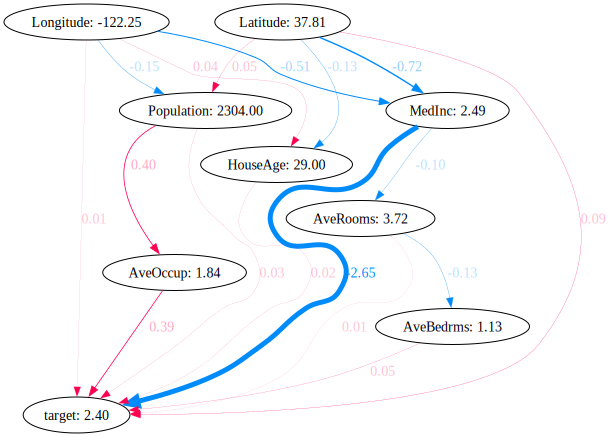

In [4]:
# --- Build the DAG --------------------------------------------------------
# Node names MUST match X column names exactly -- GraphExplainer looks up
# values from the DataFrame by node name.  shapflow calls each mechanism in
# a *vectorised* fashion: parent values arrive as 1-D arrays (one entry per
# background row), and the mechanism must return a 1-D array of matching
# length.  The toy DAG's `lambda x1: 1 - x1` worked because numpy broadcasts
# arithmetic; sklearn's predict() does not, so we wrap it.
def _mech(aux):
    """Adapt a fitted sklearn regressor to shapflow's vectorised mechanism API.

    Returns a function that takes one or more parent vectors, stacks them
    column-wise into a 2-D design matrix, and returns the regressor's 1-D
    prediction vector.  Works for any number of parents (>=1).
    """
    def mech(*parents):
        cols = [np.atleast_1d(np.asarray(p, dtype=float)).ravel() for p in parents]
        return aux.predict(np.column_stack(cols))
    return mech

lat        = Node("Latitude")
lon        = Node("Longitude")
medInc     = Node("MedInc",     _mech(aux_medInc),     [lat, lon])
houseAge   = Node("HouseAge",   _mech(aux_houseAge),   [lat, lon])
population = Node("Population", _mech(aux_population), [lat, lon])
aveRooms   = Node("AveRooms",   _mech(aux_aveRooms),   [medInc])
aveBedrms  = Node("AveBedrms",  _mech(aux_aveBedrms),  [aveRooms])
aveOccup   = Node("AveOccup",   _mech(aux_aveOccup),   [population])

def target_mech(mi, ha, ar, ab, pp, ao, la, lo):
    # Feature order MUST match the order the RandomForestRegressor was fitted with,
    # which equals data['feature_names'] (printed above).
    # We wrap the parent values in a pd.DataFrame with the same columns the RF
    # was trained on; otherwise sklearn warns about "X does not have valid
    # feature names" on every single call (shapflow makes a *lot* of them).
    cols = [np.atleast_1d(np.asarray(v, dtype=float)).ravel()
            for v in (mi, ha, ar, ab, pp, ao, la, lo)]
    X_input = pd.DataFrame(np.column_stack(cols), columns=feature_names)
    return trained_rf.predict(X_input)

target = Node(
    "target", target_mech,
    [medInc, houseAge, aveRooms, aveBedrms, population, aveOccup, lat, lon],
    is_target_node=True,
)

g_california = Graph([lat, lon, medInc, houseAge, population,
                       aveRooms, aveBedrms, aveOccup, target])

# --- Run flow -------------------------------------------------------------
t0 = time.time()
flow_california = GraphExplainer(g_california, X_background, silent=True).shap_values(X_eval)
ca_runtime = time.time() - t0

print(f"\nShapleyFlow runtime on California ({N_EVAL} instances): {ca_runtime:.1f}s")
print(f"  per-instance ~ {ca_runtime / N_EVAL:.1f}s")

# Edge-level attribution for the first explained instance.
print("\nEdge attributions for sample 0:")
show_edge_credits(flow_california, 0)

## Why not Ames and Covertype?

ShapleyFlow needs an honest causal DAG with mechanisms for every non-root node. For the other two project datasets that requirement is not satisfiable in a defensible way:

* **Ames Housing (~79 features).** Many features are categorical (label-encoded by the loader), many are quasi-redundant (`GarageYrBlt` vs `YearBuilt`, `1stFlrSF` vs `TotalBsmtSF`, ...), and there is no published causal graph for them. Hand-crafting a 79-node DAG with mechanisms would be guesswork at scale and the resulting edge attributions would tell us more about our DAG than about the model.
* **Forest Covertype (54 features).** 40 of the 54 features are one-hot-encoded soil-type indicators and 4 are one-hot wilderness areas — these are not causally related to each other in any meaningful way (a forest patch is in exactly one wilderness area; the one-hots are *deterministic* given a single underlying categorical). Furthermore the repo trains a `RandomForestRegressor` on the integer class labels 1..7 rather than a classifier, so the target node would be decomposing a regressed integer score, which is hard to read.

California is the sweet spot: 8 semantically meaningful features (geographic + demographic) where a defensible DAG can be written down, and the same `RandomForestRegressor` that the other notebooks on this branch already use. Anyone wanting to extend ShapleyFlow to Ames or Covertype would need to first commit to a documented causal story for those features — that's a separate research artifact, not a benchmarking exercise.